# Drift detection: Wright–Fisher and FIT

Simulating unbiased and biased frequency trajectories, then applying the Frequency Increment Test (FIT).

Completed version of the student notebook.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
from tqdm.notebook import tqdm

# setting the style for seaborn plots
sns.set(context="paper", style="ticks", 
        font_scale=1, palette="colorblind")

# setting a random seed for reproducibility
rng = np.random.default_rng(20260927)

### 0. Unbiased copying with multiple variants. 

During our last class, we used the model where there were only two cultural variants: A and B. What happens when you start with multiple variants, and mutation happens not by changing one variant for another, but rather by adding a new variants instead (which is more ecological). 

Let's replicate the model from [Bentley et al. 2004](https://doi.org/10.1098/rspb.2004.2746).

In [18]:
def simulate_with_innovation(N, k, t, mu, rng):
    """
    N -- population size
    k -- number of initial variants
    t -- number of time steps
    mu -- mutation/innovation rate (probability of a new variant 
    entering the population)
    rng -- random number generator
    """
    # Initial variants: 0, 1, ..., k-1
    population = rng.choice(np.arange(k), size=N)

    populations = [population.copy()]
    next_variant = k

    for _ in range(t):

        # Copying: each agent randomly chooses a 
        # cultural variant from the population
        population = rng.choice(
            population,
            size=N,
            replace=True
        )

        # Innovation: index of agents that will innovate
        innovators = rng.random(N) < mu

        # Assign new variants to innovators
        for i in np.where(innovators)[0]:
            # add a new index for the new variant
            population[i] = next_variant
            # if new variant is added, increment the next_variant counter
            next_variant += 1

        # save all populations for later analysis
        populations.append(population.copy())

    # Frequency of every variant that ever existed
    # stored as a matrix of shape (t+1, next_variant)
    frequencies = np.zeros((t + 1, next_variant))

    for time, pop in enumerate(populations):
        for v in np.unique(pop):
            # compute the frequency of variant v at time step time
            frequencies[time, v] = np.mean(pop == v)

    return frequencies

In [19]:
result = simulate_with_innovation(
    N=10_000,
    k=100,
    t=100,
    mu=0.005,
    rng=rng
)

Now let's plot the rank-frequency distributions for the initial run, and the final run. What do you notice? Do not forget to remove zeroed frequencies, as our `frequencies` matrix is containig all possible wariants, which might dissapear overtime.

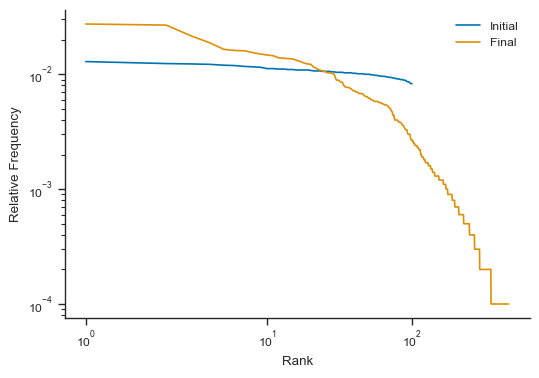

In [20]:
# Obtain the initial and final frequency distributions of variants,
# sorted in descending order.
initial = np.sort(result[0])[::-1]
final = np.sort(result[-1])[::-1]

# Remove zero-frequency variants from both arrays.
initial = initial[initial > 0]
final = final[final > 0]

ranks_initial = np.arange(1, len(initial) + 1)
ranks_final = np.arange(1, len(final) + 1)

plt.figure(figsize=(6, 4))

plt.plot(ranks_initial, initial, label="Initial")
plt.plot(ranks_final, final, label="Final")

plt.xscale("symlog")
plt.yscale("log")

# plt.xlim(1, 700)

plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.legend(frameon=False)
sns.despine()
plt.show()

Now rerun the model with a small t of 10 or 20, and plot individual frequencies of randomly sampled variants over-time. What do you notice? Do not forget to normalize frequency values to make them comparable -- you can divide them by variance. 

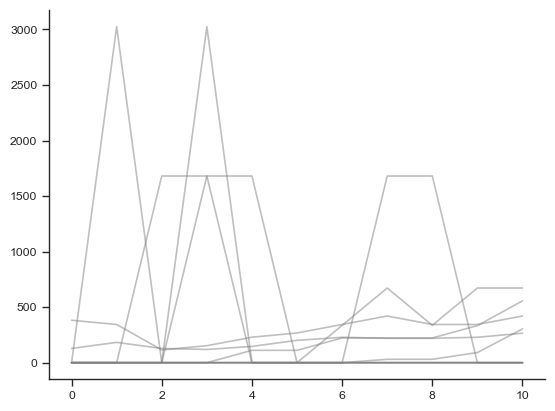

In [21]:
# Rerun the simulation, then plot 10 random variant trajectories.
# Normalize each by its variance.
result = simulate_with_innovation(
    N=250,
    k=20,
    t=10,
    mu=0.032,
    rng=rng
)

for i in rng.choice(result.shape[1], size=10, replace=False):
    variance = np.var(result[:, i])
    if variance > 0:
        plt.plot(result[:, i] / variance, alpha=0.5, color="gray")

sns.despine()
plt.show()

## 1. Adding selection to the model with two cultural variants.

### 1.1. Initializing the model. 

A population has two cultural traits, **A** and **B**. In each generation, the next population contains $N$ independent draws. If the current frequency of A is $p$, an unbiased model samples with probability $p$.

To add directional bias, let A have relative fitness $1+s$ and B have relative fitness 1. $s$ will then correspond to selection for A. To implement this in our model, you would need to perform weighted sampling where every A has weight $1+s$ and B has weight 1. 

In [22]:
def simulate_run(N, p_init, t, selection, rng):
    """
    N -- population size
    p_init -- initial proportion of variant A
    t -- number of time steps
    selection -- selection coefficient for variant A
    rng -- random number generator
    """

    items = ["A", "B"]

    # randomly initialize the population with a given proportion of A and B
    population = rng.choice(
        items,
        size=N,
        p=[p_init, 1 - p_init]
    )

    frequencies = [np.mean(population == "A")]

    for _ in range(t):

        # Assign A weight 1 + selection and B weight 1.
        weights = np.where(population == "A", 1 + selection, 1)

        # Normalize weights to sum to 1
        weights = weights / weights.sum()

        # New generation copies individuals according to their variants' fitness
        # A are more likely to be copied than B if selection > 0
        population = rng.choice(
            population,
            size=N,
            replace=True,
            p=weights
        )

        # append the frequency of A in the current population to the frequencies list
        frequencies.append(np.mean(population == "A"))

    return np.array(frequencies)

Let's compare one unbiased run with one biased run. What do you notice about how frequency of A changes?

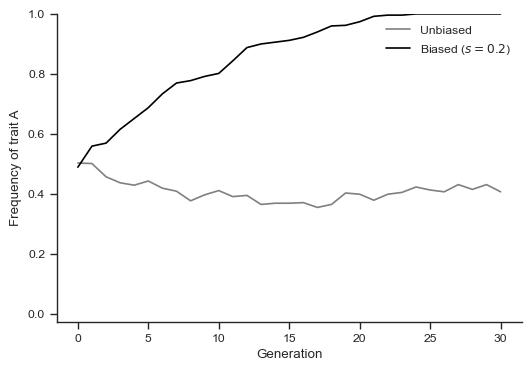

In [23]:
N = 5_00
p_init = 0.5
t = 30
selection = 0.2

unbiased_run = simulate_run(N, p_init, t, selection=0, rng=rng)
biased_run = simulate_run(N, p_init, t, selection=selection, rng=rng)

plt.figure(figsize=(6, 4))
plt.plot(unbiased_run, color="grey", label="Unbiased")
plt.plot(biased_run, color="black", label=f"Biased ($s={selection}$)")
plt.xlabel("Generation")
plt.ylabel("Frequency of trait A")
plt.ylim(-0.025, 1)
plt.legend(frameon=False)
sns.despine()
plt.show()

### 1.2. Repeating multiple runs. What is the difference across conditions?

One run is only one possible outcome. Repeating the model shows the distribution of trajectories produced by drift and bias.

In [24]:
num_runs = 200

unbiased = np.array([
    simulate_run(N, p_init, t, selection=0, rng=rng)
    for _ in range(num_runs)
])
biased = np.array([
    simulate_run(N, p_init, t, selection=selection, rng=rng)
    for _ in range(num_runs)
])

assert unbiased.shape == biased.shape == (num_runs, t + 1)

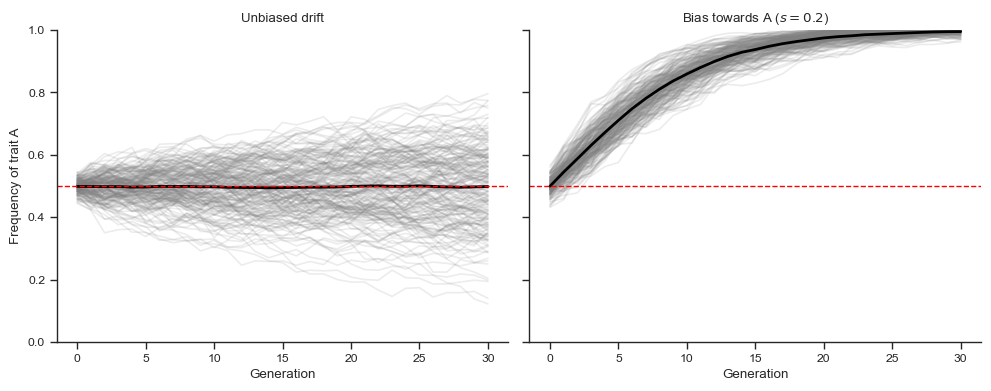

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, simulations, title in zip(
    axes, [unbiased, biased], ["Unbiased drift", f"Bias towards A ($s={selection}$)"]
):
    ax.plot(simulations.T, color="grey", alpha=0.15)
    ax.plot(simulations.mean(axis=0), color="black", linewidth=2)
    ax.axhline(p_init, color="red", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Frequency of trait A")
sns.despine()
plt.tight_layout()
plt.show()

The distributions of final frequencies make the difference visible: unbiased drift stays centred near the starting frequency, while directional bias shifts the distribution towards A.

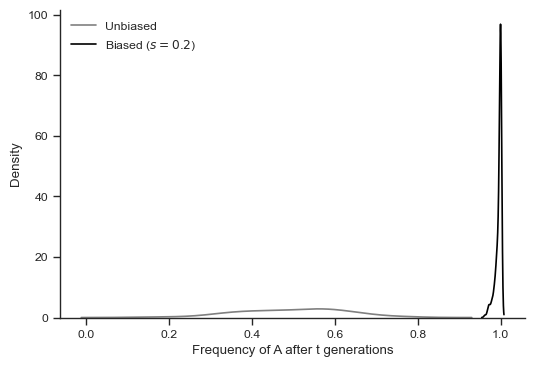

In [26]:
plt.figure(figsize=(6, 4))
sns.kdeplot(unbiased[:, -1], color="grey", label="Unbiased")
sns.kdeplot(biased[:, -1], color="black", label=f"Biased ($s={selection}$)")
plt.xlabel("Frequency of A after t generations")
plt.ylabel("Density")
plt.legend(frameon=False)
sns.despine()
plt.show()

## 2. Frequency Increment Test (FIT)

In class, we talked about the frequency increment test as a way of detecting drift given a frequency distribution over time t. How does it work? 

For each one-generation interval, FIT standardizes the frequency increment as

$$Y_t = \frac{p_t - p_{t-1}}{\sqrt{2p_{t-1}(1-p_{t-1})}}.$$

Under neutral drift, the mean of the $Y_t$ values should be close to zero. FIT therefore uses a one-sample t-test to test whether the mean of $Y_t$ is equal to zero. The denominator is undefined when $p_{t-1}$ is 0 or 1, so those intervals are omitted.

In [27]:
def fit(frequencies):
    """
    Given a list of frequencies, compute fit and return the test 
    statistic, p-value and the list of increments. 
    """
    previous = frequencies[:-1]
    valid = (previous > 0) & (previous < 1)
    # define p_t - p_{t-1}
    increments = np.diff(frequencies)[valid]
    # Standardize the increments using the FIT formula above.
    increments = increments / np.sqrt(2 * previous[valid] * (1 - previous[valid]))

    if len(increments) < 2:
        return np.nan, np.nan, increments

    result = ttest_1samp(increments, 0)
    return result.statistic, result.pvalue, increments

Previosly we generated a bunch of runs from the biased and the unbiased models. Apply FIT separately to every simulated trajectory. Count the number of runs that have p < 0.05, how well does FIT do? Are there false positives? False negatives?

In [28]:
unbiased_fit = [fit(run) for run in unbiased]
biased_fit = [fit(run) for run in biased]

unbiased_t = np.array([result[0] for result in unbiased_fit])
unbiased_p = np.array([result[1] for result in unbiased_fit])
biased_t = np.array([result[0] for result in biased_fit])
biased_p = np.array([result[1] for result in biased_fit])

for label, t_values, p_values in [
    ("Unbiased", unbiased_t, unbiased_p),
    ("Biased", biased_t, biased_p),
]:
    # Find the fraction of runs with p < 0.05.
    fraction_rejected = np.mean(p_values < 0.05)
    print(f"{label}: mean FIT statistic = {np.nanmean(t_values):.2f}, "
          f"fraction with p < 0.05 = {fraction_rejected:.2f}")

assert np.isfinite(unbiased_p).all() and np.isfinite(biased_p).all()

Unbiased: mean FIT statistic = -0.00, fraction with p < 0.05 = 0.06
Biased: mean FIT statistic = 5.44, fraction with p < 0.05 = 1.00


## 3. Selection and frequency resolution

How does FIT depend on the strength of selection and on how finely we represent frequencies? We assign each observation to an equal-width frequency bin, replace it with the mean frequency observed in that bin, and record FIT rejections over 10 runs. The $s=0$ row estimates the false-positive rate; rows with selection show detection rates.

We will try to replicate the results from [Karsdorp et al. 2020](https://doi.org/10.1017/ehs.2020.52), more Panel 1 of their Figure 3. 

Let's define a function for binning. 

In [29]:
def bin_frequencies(frequencies, n_bins):
    frequencies = np.asarray(frequencies)

    bins = np.array_split(frequencies, n_bins)

    # Replace each bin with its mean frequency.
    return np.array([
        b.mean()
        for b in bins
    ])

Apply it to the same run and compare the results.

In [30]:
for i in range(5):
    print(f"Run {i + 1}:")
    print("Unbiased:", bin_frequencies(unbiased[i], n_bins=10))
    print("Biased:", bin_frequencies(biased[i], n_bins=10))
    print()

Run 1:
Unbiased: [0.477      0.474      0.43733333 0.37333333 0.37       0.33
 0.256      0.238      0.212      0.21      ]
Biased: [0.5145     0.67466667 0.81866667 0.898      0.936      0.96866667
 0.98866667 0.99333333 0.99933333 1.        ]

Run 2:
Unbiased: [0.5085     0.53733333 0.53933333 0.494      0.51133333 0.51933333
 0.48866667 0.58933333 0.612      0.54133333]
Biased: [0.591      0.734      0.80933333 0.856      0.91066667 0.94333333
 0.962      0.986      0.996      0.99933333]

Run 3:
Unbiased: [0.5155     0.50533333 0.496      0.462      0.49266667 0.53733333
 0.55933333 0.576      0.53       0.544     ]
Biased: [0.5485     0.674      0.758      0.84666667 0.93666667 0.96066667
 0.97133333 0.99       0.994      0.994     ]

Run 4:
Unbiased: [0.5225     0.52066667 0.558      0.53333333 0.538      0.50533333
 0.45933333 0.4        0.35266667 0.30133333]
Biased: [0.6245     0.79333333 0.85466667 0.86133333 0.894      0.94066667
 0.96533333 0.97333333 0.98666667 0.98733333]

Now we can run the model under multiple selection coefficients, and bin each frequency trajectory with bin values from `bin_values`, and plot the heatmap showing the detection rate (how many runs were correctly labelled as having selection). What do you notice?

In [31]:
selection_values = np.logspace(-2, 0, 100)
bin_values = np.array([
    *range(4, 21),
    *range(30, 61, 10),
    100,
    200,
])
heatmap_runs = 10
detection_rate = np.empty((len(selection_values), len(bin_values)))

for row, selection_value in tqdm(
    enumerate(selection_values),
    total=len(selection_values),
    desc="Selection strengths",
):
    simulations = np.array([
        simulate_run(N=500, p_init=0.5, 
                     t=200, selection=selection_value, 
                     rng=rng)
        for _ in range(heatmap_runs)
    ])

    for col, num_bins in enumerate(bin_values):
        p_values = [
            fit(bin_frequencies(run, num_bins))[1]
            for run in simulations
        ]
        detection_rate[row, col] = np.mean(np.asarray(p_values) > 0.05)

Selection strengths:   0%|          | 0/100 [00:00<?, ?it/s]

We can now plot the results, which should be identical to Figure 3 from Karsdorp et al., 2020. 

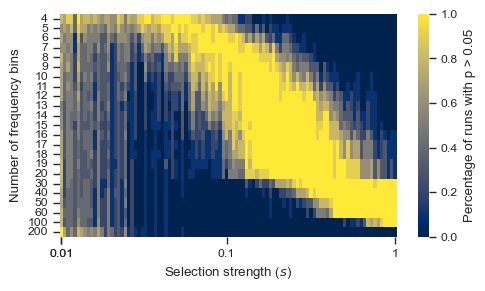

In [32]:
plt.figure(figsize=(5, 3))

ax = sns.heatmap(
    detection_rate.T,
    vmin=0,
    vmax=1,
    cmap="cividis",
    xticklabels=False,
    yticklabels=bin_values,
    cbar_kws={"label": "Percentage of runs with p > 0.05"},
)

# log-scale labels
x_ticks = [0.001, 0.01, 0.1, 1]
x_pos = [np.argmin(abs(selection_values - x)) + 0.5 for x in x_ticks]

ax.set_xticks(x_pos)
ax.set_xticklabels(["0.001", "0.01", "0.1", "1"])

plt.xlabel("Selection strength ($s$)")
plt.ylabel("Number of frequency bins")

plt.tight_layout()
plt.show()